In [1]:
!pip install statsmodels

In [1]:
import pandas as pd
import numpy as np
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
url = "https://gksmyth.github.io/ozdasl/oz/stroke.txt"
df = pd.read_csv(url, sep="\t")  # 区切りがタブっぽいので \t を指定

In [3]:
df.head()

,Subject,Group,Sex,Side,Age,Lapse,UE1,UE2,UE3,UE4,...,Bal7,Bal8,Bart1,Bart2,Bart3,Bart4,Bart5,Bart6,Bart7,Bart8
0,I,E,M,R,74,11.0,15,23,23,26,...,10,10,45,45,45,45,80,80,80,90
1,II,E,M,L,61,2.0,3,3,3,5,...,8,8,20,25,25,25,30,35,30,50
2,III,E,M,R,49,6.0,2,2,4,7,...,10,10,50,50,55,70,70,75,90,90
3,IV,E,M,L,68,1.0,14,25,25,31,...,9,9,25,25,35,40,60,60,70,80
4,V,E,M,R,55,33.0,22,22,22,22,...,12,12,100,100,100,100,100,100,100,100


In [4]:
usecols = [
    "Subject",
    "Group",
    "Bart1",
    "Bart2",
    "Bart3",
    "Bart4",
    "Bart5",
    "Bart6",
    "Bart7",
    "Bart8",
]
df = df[usecols]

# 図11.2の再現

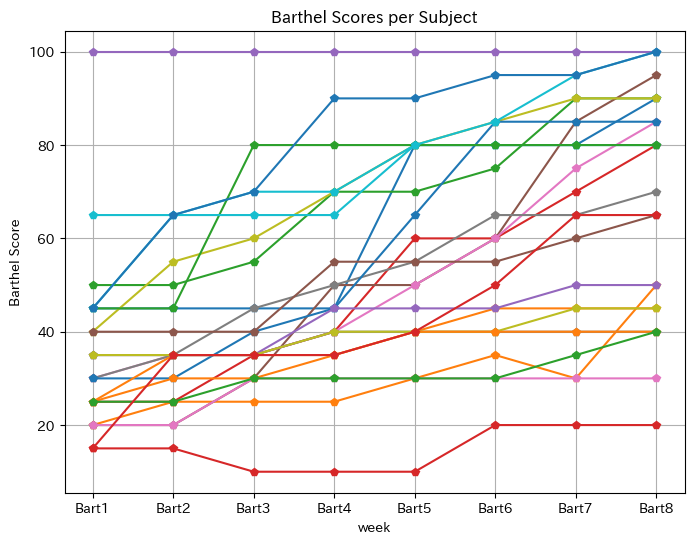

In [5]:
# Bart列だけ抽出
bart_cols = [f"Bart{i}" for i in range(1, 9)]

# プロット
plt.figure(figsize=(8, 6))
for idx, row in df.iterrows():
    plt.plot(bart_cols, row[bart_cols], marker="p", label=row["Subject"])

plt.title("Barthel Scores per Subject")
plt.xlabel("week")
plt.ylabel("Barthel Score")
# plt.legend(title="Subject")
plt.grid(True)
plt.show()

# 図11.3の再現

In [6]:
df_group = df.drop(["Subject"], axis=1).groupby("Group").mean().reset_index()
df_group

,Group,Bart1,Bart2,Bart3,Bart4,Bart5,Bart6,Bart7,Bart8
0,E,40.000,41.875,46.25,52.500,61.875,66.875,74.375,82.500
1,F,36.875,40.000,46.25,51.250,56.875,61.875,63.750,64.375
2,G,30.625,38.750,41.25,45.625,48.750,51.250,55.625,57.500


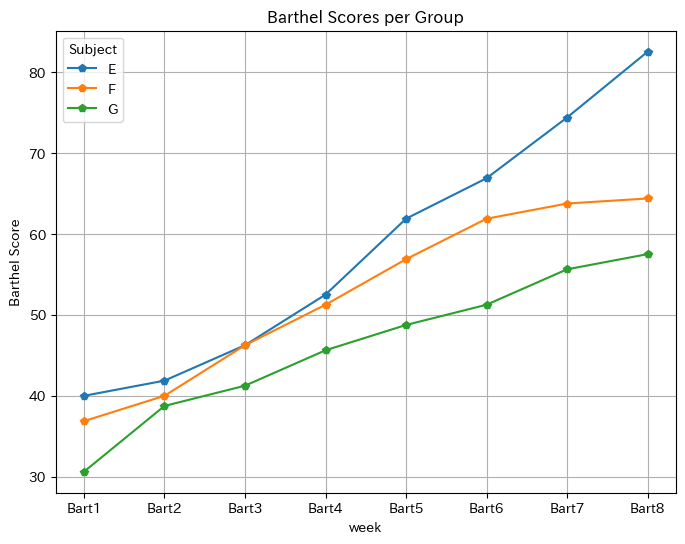

In [7]:
# Bart列だけ抽出
bart_cols = [f"Bart{i}" for i in range(1, 9)]

# プロット
plt.figure(figsize=(8, 6))
for idx, row in df_group.iterrows():
    plt.plot(bart_cols, row[bart_cols], marker="p", label=row["Group"])

plt.title("Barthel Scores per Group")
plt.xlabel("week")
plt.ylabel("Barthel Score")
plt.legend(title="Subject")
plt.grid(True)
plt.show()

# 図11.4の再現

<Figure size 600x600 with 0 Axes>

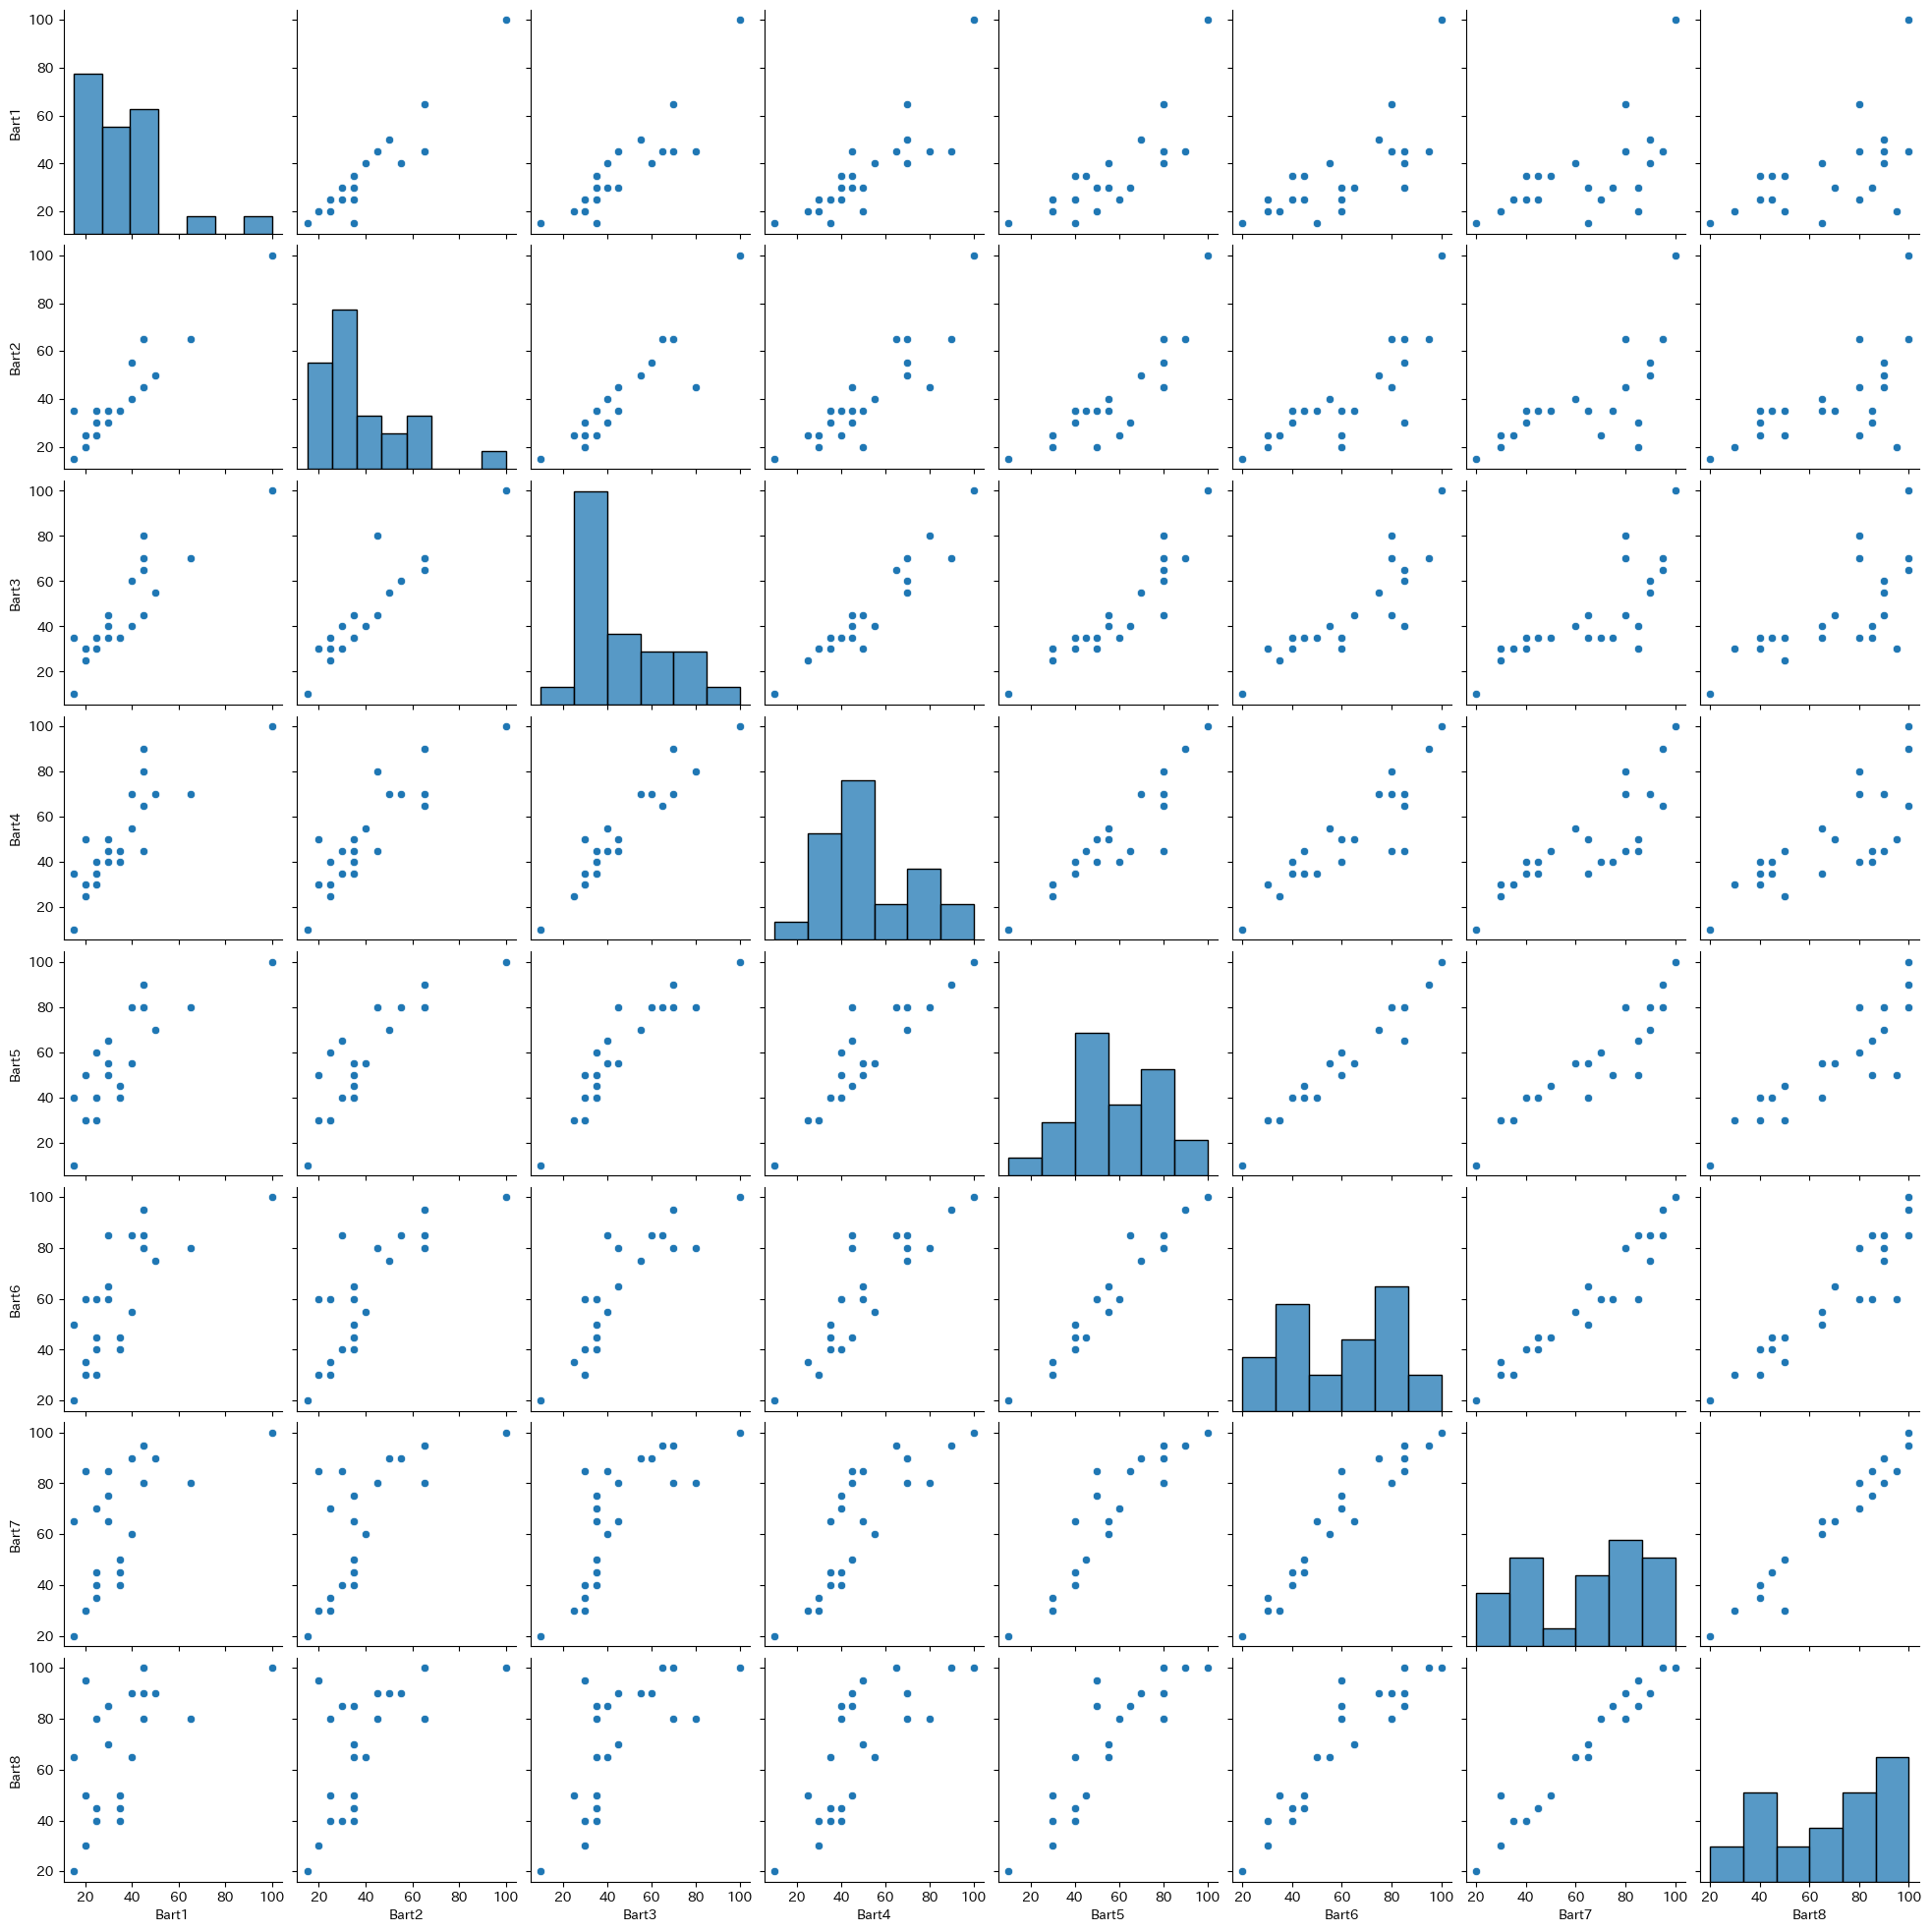

In [8]:
df_scatter = df.drop(["Subject", "Group"], axis=1)
plt.figure(figsize=(6, 6))
sns.pairplot(df_scatter, diag_kind="hist")
plt.show()

# 表11.2の再現

In [9]:
df_scatter.corr().round(2)

,Bart1,Bart2,Bart3,Bart4,Bart5,Bart6,Bart7,Bart8
Bart1,1.00,0.93,0.88,0.83,0.79,0.71,0.62,0.55
Bart2,0.93,1.00,0.92,0.88,0.85,0.79,0.70,0.64
Bart3,0.88,0.92,1.00,0.95,0.91,0.85,0.77,0.70
Bart4,0.83,0.88,0.95,1.00,0.92,0.88,0.83,0.77
Bart5,0.79,0.85,0.91,0.92,1.00,0.97,0.91,0.88
Bart6,0.71,0.79,0.85,0.88,0.97,1.00,0.96,0.93
Bart7,0.62,0.70,0.77,0.83,0.91,0.96,1.00,0.98
Bart8,0.55,0.64,0.70,0.77,0.88,0.93,0.98,1.00


#### (11.1)のモデルの係数推定

In [10]:
# Groupをダミー変数にする（alpha）
dummy = pd.get_dummies(df["Group"], columns=["Group"]).astype(int)
dummy = dummy.loc[np.repeat(dummy.index, 8)].reset_index(drop=True)

# 分散分析しやすいようにデータ加工
X = (
    df.drop(["Subject", "Group"], axis=1)
    .stack()
    .reset_index()
    .drop(["level_0"], axis=1)
    .rename(columns={"level_1": "week", 0: "Berthel_Score"})
)
X = pd.concat([dummy, X], axis=1)

# 推定対象はalpha2, alpha3ではなく、alpha2 - alpha1, alpha3 - alpha1 とみなすので、
# 基準のとなるEはすべて１とする
X["E"] = 1

# weekはそのまま数字を入れる（beta）
X["week"] = X["week"].str[4:].astype(int)

# 目的変数と説明変数に分ける
y = X["Berthel_Score"].values
X = X[["E", "F", "G", "week"]].values

# (11.1)の係数を最小二乗法により推定
estimate_11_1 = np.linalg.inv(X.T @ X) @ X.T @ y

# 不偏分散は(6.4)式で求める
unbiased_var = (
    (y - X @ estimate_11_1).T @ (y - X @ estimate_11_1) / (len(y) - X.shape[1])
)

# 標準誤差は下記の式で求められる
std_error = np.diag(np.sqrt(np.linalg.inv(X.T @ X) * unbiased_var))

df_11_1 = pd.DataFrame(
    {
        "推定値": [
            estimate_11_1[0],
            estimate_11_1[1],
            estimate_11_1[2],
            estimate_11_1[3],
        ],
        "標準誤差": std_error,
    },
    index=[
        "alpha1 (モデル11.1)",
        "alpha2 - alpha1 (モデル11.1)",
        "alpha3 - alpha1 (モデル11.1)",
        "beta (モデル11.1)",
    ],
)

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_15947/1809169634.py:27: RuntimeWarning: invalid value encountered in sqrt
  std_error = np.diag(np.sqrt(np.linalg.inv(X.T@X)*unbiased_var))


In [11]:
df_11_1

,推定値,標準誤差
alpha1 (モデル11.1),36.841518,3.971200
alpha2 - alpha1 (モデル11.1),-5.625000,3.714717
alpha3 - alpha1 (モデル11.1),-12.109375,3.714717
beta (モデル11.1),4.764385,0.661867


#### (11.2) のモデルの係数推定

In [12]:
# Groupをダミー変数にする（alpha）
dummy = pd.get_dummies(df["Group"], columns=["Group"]).astype(int)
dummy = dummy.loc[np.repeat(dummy.index, 8)].reset_index(drop=True)

# 分散分析しやすいようにデータ加工
X = (
    df.drop(["Subject", "Group"], axis=1)
    .stack()
    .reset_index()
    .drop(["level_0"], axis=1)
    .rename(columns={"level_1": "week", 0: "Berthel_Score"})
)
X = pd.concat([dummy, X], axis=1)

# weekはそのまま数字を入れる（beta）
X["week"] = X["week"].str[4:].astype(int)
X["beta1_week"] = X["E"] * X["week"]
X["beta2_week"] = X["F"] * X["week"]
X["beta3_week"] = X["G"] * X["week"]

# 推定対象はalpha2, alpha3ではなく、alpha2 - alpha1, alpha3 - alpha1 とみなすので、
# 基準のとなるEはすべて１とする
# beta1, beta2, beta3 についても同様
X["E"] = 1
X["beta1_week"] = [1, 2, 3, 4, 5, 6, 7, 8] * 24

# 目的変数と説明変数に分ける
y = X["Berthel_Score"].values
X = X[["E", "F", "G", "beta1_week", "beta2_week", "beta3_week"]].values

# (11.1)の係数を最小二乗法により推定
estimate_11_2 = np.linalg.inv(X.T @ X) @ X.T @ y

# 不偏分散は(6.4)式で求める
unbiased_var = (
    (y - X @ estimate_11_2).T @ (y - X @ estimate_11_2) / (len(y) - X.shape[1])
)

# 標準誤差は下記の式で求められる
std_error = np.diag(np.sqrt(np.linalg.inv(X.T @ X) * unbiased_var))

df_11_2 = pd.DataFrame(
    {
        "推定値": [
            estimate_11_2[0],
            estimate_11_2[1],
            estimate_11_2[2],
            estimate_11_2[3],
            estimate_11_2[4],
            estimate_11_2[5],
        ],
        "標準誤差": std_error,
    },
    index=[
        "alpha1 (モデル11.2)",
        "alpha2 - alpha1 (モデル11.2)",
        "alpha3 - alpha1 (モデル11.2)",
        "beta1 (モデル11.2)",
        "beta2 -beta1 (モデル11.2)",
        "beta3 - beta1 (モデル11.2)",
    ],
)

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_15947/1708014488.py:32: RuntimeWarning: invalid value encountered in sqrt
  std_error = np.diag(np.sqrt(np.linalg.inv(X.T@X)*unbiased_var))


In [13]:
pd.concat([df_11_1, df_11_2]).round(3)

,推定値,標準誤差
alpha1 (モデル11.1),36.842,3.971
alpha2 - alpha1 (モデル11.1),-5.625,3.715
alpha3 - alpha1 (モデル11.1),-12.109,3.715
beta (モデル11.1),4.764,0.662
alpha1 (モデル11.2),29.821,5.774
alpha2 - alpha1 (モデル11.2),3.348,8.166
alpha3 - alpha1 (モデル11.2),-0.022,8.166
beta1 (モデル11.2),6.324,1.143
beta2 -beta1 (モデル11.2),-1.994,1.617
beta3 - beta1 (モデル11.2),-2.686,1.617


# 表11.4の再現

In [14]:
# 不要列は除外
dataset = df.drop(["Subject", "Group"], axis=1).T.reset_index()

# weekを説明変数とするため文字列を処理
dataset["index"] = dataset["index"].str[4:]

# 説明変数の作成
X = np.ones(len(dataset))
X = np.vstack([X, dataset["index"].values.astype(int)]).T

# 患者ごとに回帰する
list_coef = []
for i in range(0, 24):
    y = dataset[i].values
    beta = np.linalg.inv(X.T @ X) @ X.T @ y

    # 不偏分散
    sigma_sq = (y - X @ beta).T @ (y - X @ beta) / (len(dataset) - X.shape[1])

    # 標準誤差
    std_error = np.diag(np.sqrt(np.linalg.inv(X.T @ X) * sigma_sq))

    list_coef.append(np.hstack([beta, std_error]))

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_15947/3304566838.py:21: RuntimeWarning: invalid value encountered in sqrt
  std_error = np.diag(np.sqrt(np.linalg.inv(X.T@X)*sigma_sq))


In [15]:
pd.DataFrame(
    list_coef, columns=["切片", "傾き", "標準誤差（切片）", "標準誤差（傾き）"]
).round(3)

,切片,傾き,標準誤差（切片）,標準誤差（傾き）
0,30.000,7.500,7.289,1.443
1,15.536,3.214,4.099,0.812
2,39.821,6.429,3.209,0.636
3,11.607,8.393,3.387,0.671
4,100.000,-0.000,0.000,0.000
5,0.893,11.190,5.304,1.050
6,15.357,7.976,4.669,0.925
7,25.357,5.893,1.971,0.390
8,38.571,7.262,3.522,0.698
9,61.964,2.619,2.236,0.443


# 表11.5の再現

In [16]:
from scipy.stats import f

In [17]:
tmp = pd.concat(
    [
        df["Group"],
        pd.DataFrame(
            list_coef, columns=["intercept", "slope", "SE_intercept", "SE_slope"]
        ),
    ],
    axis=1,
)
tmp

,Group,intercept,slope,SE_intercept,SE_slope
0,E,30.000000,7.500000e+00,7.288690e+00,1.443376e+00
1,E,15.535714,3.214286e+00,4.099372e+00,8.117965e-01
2,E,39.821429,6.428571e+00,3.209322e+00,6.355404e-01
3,E,11.607143,8.392857e+00,3.387370e+00,6.707993e-01
4,E,100.000000,-5.329071e-15,2.557202e-14,5.064014e-15
5,E,0.892857,1.119048e+01,5.303635e+00,1.050276e+00
6,E,15.357143,7.976190e+00,4.669490e+00,9.246968e-01
7,E,25.357143,5.892857e+00,1.971038e+00,3.903237e-01
8,F,38.571429,7.261905e+00,3.522482e+00,6.975554e-01
9,F,61.964286,2.619048e+00,2.235910e+00,4.427761e-01


In [20]:
pd.get_dummies(tmp["Group"], columns=["Group"])

,E,F,G
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,True,False,False
6,True,False,False
7,True,False,False
8,False,True,False
9,False,True,False


In [27]:
# 一元配置分散分析によるパラメータ推定
X = pd.get_dummies(tmp["Group"], columns=["Group"]).astype(int)
X["E"] = 1
X = X.values
y = tmp["intercept"].values

In [28]:
X

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1],
       [1, 0, 1]])

In [22]:
# パラメータを最小二乗法で推定
alpha = np.linalg.inv(X.T @ X) @ X.T @ y

# 表11.5を作成
table_11_5 = pd.DataFrame(
    {
        "変動要因": ["群", "誤差"],
        "d.f.": [len(alpha) - 1, len(tmp) - 3],
        "平方和": [((X @ alpha - y.mean()) ** 2).sum(), ((y - X @ alpha) ** 2).sum()],
    }
)
table_11_5["平均平方"] = table_11_5["平方和"] / table_11_5["d.f."]
table_11_5["F"] = [
    table_11_5["平均平方"].values[0] / table_11_5["平均平方"].values[1],
    "-",
]

# 自由度
df1 = 2
df2 = 21

# 閾値
F_value = table_11_5["平均平方"].values[0] / table_11_5["平均平方"].values[1]

# 累積分布関数 (P(F <= F_value))
p_cdf = f.cdf(F_value, df1, df2)

# 超える確率 (右側確率)
p_right = 1 - p_cdf

# p値を格納
table_11_5["p値(>F)"] = [p_right, "-"]

# 不偏分散
sigma_sq = (y - X @ alpha).T @ (y - X @ alpha) / (len(X) - X.shape[1])

# 標準誤差
std_error = np.diag(np.sqrt(np.linalg.inv(X.T @ X) * sigma_sq))

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_15947/1444226798.py:35: RuntimeWarning: invalid value encountered in sqrt
  std_error = np.diag(np.sqrt(np.linalg.inv(X.T@X)*sigma_sq))


In [23]:
np.set_printoptions(suppress=True)  # 指数表記を抑制
display(table_11_5)
pd.DataFrame(
    {
        "パラメータ": ["alpha1", "alpha2-alpha1", "alpha3-alpha1"],
        "推定値": alpha.round(3),
        "標準誤差": std_error.round(3),
    }
)

,変動要因,d.f.,平方和,平均平方,F,p値(>F)
0,群,2,60.190795,30.095398,0.065611,0.936686
1,誤差,21,9632.537468,458.692260,-,-


,パラメータ,推定値,標準誤差
0,alpha1,29.821,7.572
1,alpha2-alpha1,3.348,10.709
2,alpha3-alpha1,-0.022,10.709


#### 参考：statsmodelsによる再現

In [21]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 切片
model_intercept = ols("intercept ~ Group", data=tmp[["intercept", "Group"]]).fit()
anova_intercept = sm.stats.anova_lm(model_intercept, typ=2)
print(anova_intercept)

               sum_sq    df         F    PR(>F)
Group       60.190795   2.0  0.065611  0.936686
Residual  9632.537468  21.0       NaN       NaN


# 表11.6の再現

In [22]:
# 一元配置分散分析によるパラメータ推定
X = pd.get_dummies(tmp["Group"], columns=["Group"]).astype(int)
X["E"] = 1
X = X.values
y = tmp["slope"].values

# パラメータを最小二乗法で推定
beta = np.linalg.inv(X.T @ X) @ X.T @ y

# 表11.5を作成
table_11_6 = pd.DataFrame(
    {
        "変動要因": ["群", "誤差"],
        "d.f.": [len(beta) - 1, len(tmp) - 3],
        "平方和": [((X @ beta - y.mean()) ** 2).sum(), ((y - X @ beta) ** 2).sum()],
    }
)
table_11_6["平均平方"] = table_11_6["平方和"] / table_11_6["d.f."]
table_11_6["F"] = [
    table_11_6["平均平方"].values[0] / table_11_6["平均平方"].values[1],
    "-",
]

# 自由度
df1 = 2
df2 = 21

# 閾値
F_value = table_11_6["平均平方"].values[0] / table_11_6["平均平方"].values[1]

# 累積分布関数 (P(F <= F_value))
p_cdf = f.cdf(F_value, df1, df2)

# 超える確率 (右側確率)
p_right = 1 - p_cdf

# p値を格納
table_11_6["p値(>F)"] = [p_right, "-"]

# 不偏分散
sigma_sq = (y - X @ beta).T @ (y - X @ beta) / (len(X) - X.shape[1])

# 標準誤差
std_error = np.diag(np.sqrt(np.linalg.inv(X.T @ X) * sigma_sq))

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_28689/3820272568.py:41: RuntimeWarning: invalid value encountered in sqrt
  std_error = np.diag(np.sqrt(np.linalg.inv(X.T@X)*sigma_sq))


In [23]:
display(table_11_6)
pd.DataFrame(
    {
        "パラメータ": ["beta1", "beta2-beta1", "beta3-beta1"],
        "推定値": beta.round(3),
        "標準誤差": std_error.round(3),
    }
)

,変動要因,d.f.,平方和,平均平方,F,p値(>F)
0,群,2,31.119201,15.559601,1.666111,0.213007
1,誤差,21,196.116337,9.338873,-,-


,パラメータ,推定値,標準誤差
0,beta1,6.324,1.080
1,beta2-beta1,-1.994,1.528
2,beta3-beta1,-2.686,1.528
